# DECISION TREE

**1. Data Preparation:**

In [ ]:
##importig libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

**Exploratory Data Analysis (EDA)**

In [ ]:
df = pd.read_excel("heart_disease.xlsx",
                   sheet_name="Heart_disease")

print("First 5 Rows")
print(df.head())


First 5 Rows
   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [ ]:
df.duplicated().sum()

np.int64(1)

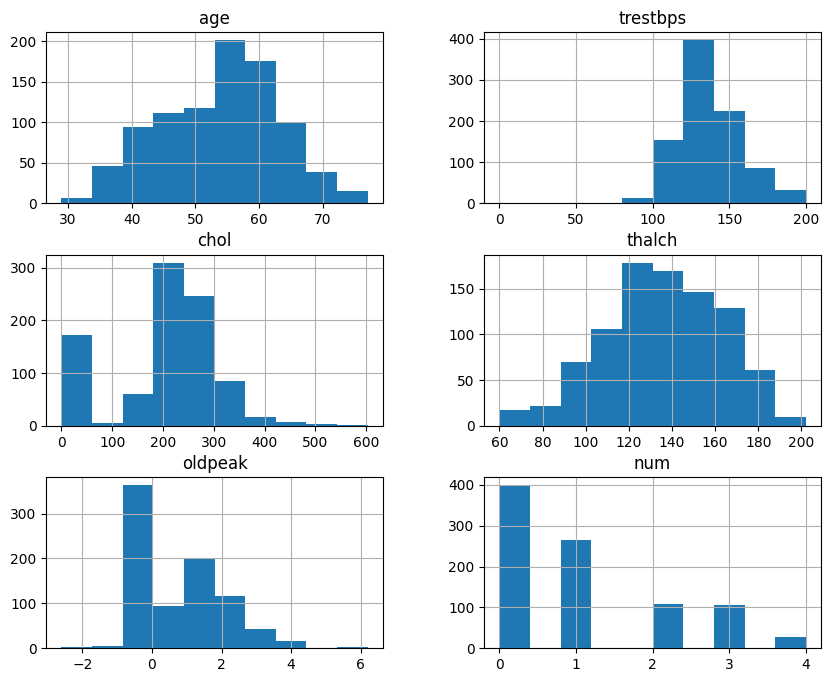

In [ ]:
##histogram
df.hist(figsize=(10,8))
plt.show()

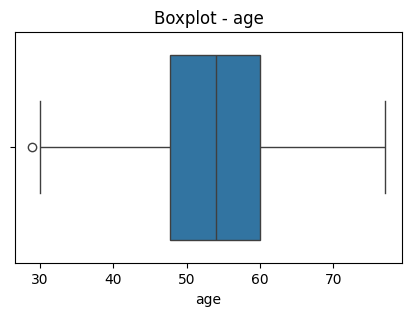

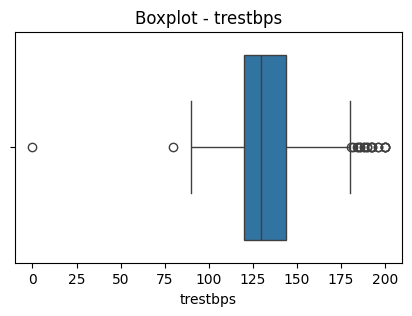

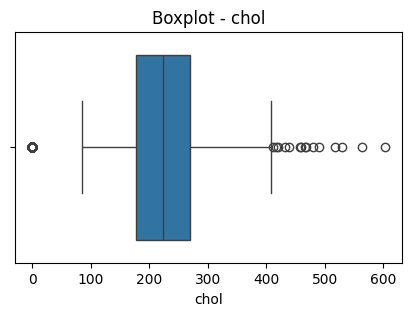

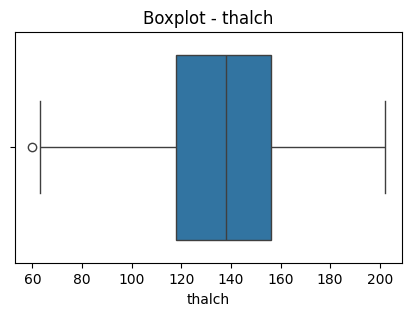

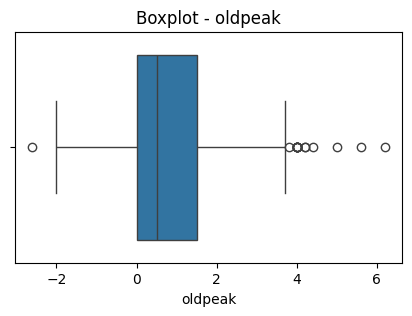

In [ ]:
# Boxplots
import pandas as pd

for col in df.columns[:-1]:
    # Only plot boxplots for numerical columns that are not boolean
    if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col]):
        plt.figure(figsize=(5,3))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot - {col}")
        plt.show()

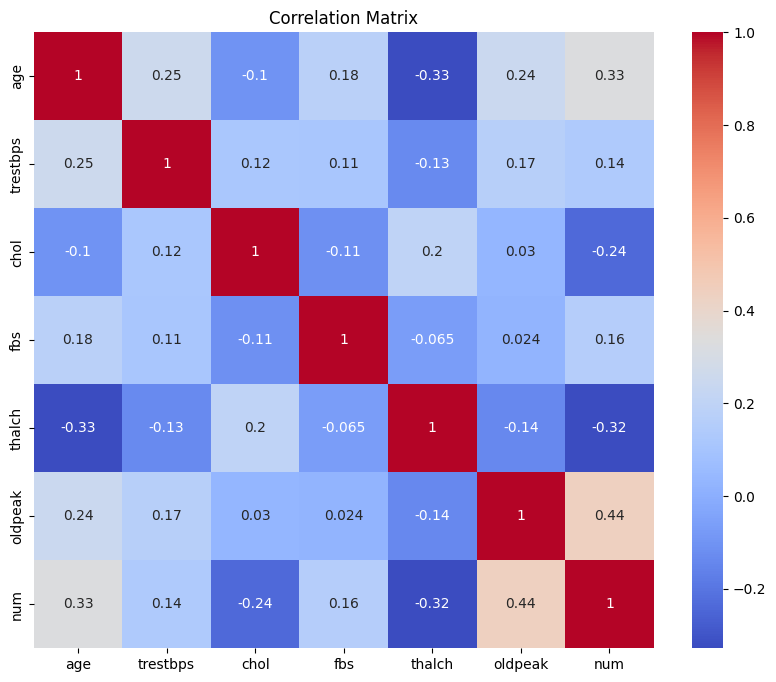

In [ ]:
# Correlation Matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

 **3. FEATURE ENGINEERING**

In [ ]:
# Encode Categorical Variables

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'sex',
    'cp',
    'restecg',
    'exang',
    'slope',
    'thal'
]

for col in categorical_cols:
    # Convert column to string type to ensure uniform input for LabelEncoder
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
# FEATURES AND TARGET

X = df.drop('num', axis=1)
y = df['num']


**4. DECISION TREE CLASSIFICATION**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Train Model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
# Prediction
y_pred = dt.predict(X_test)
y_pred_proba = dt.predict_proba(X_test)

In [ ]:
# Evaluation
print("\nAccuracy")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nROC AUC Score")
print(roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted'))


Accuracy
0.5164835164835165

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.69      0.71        89
           1       0.40      0.44      0.42        48
           2       0.29      0.32      0.30        22
           3       0.31      0.29      0.30        17
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.35      0.35      0.35       182
weighted avg       0.53      0.52      0.52       182


ROC AUC Score
0.6588136571541121


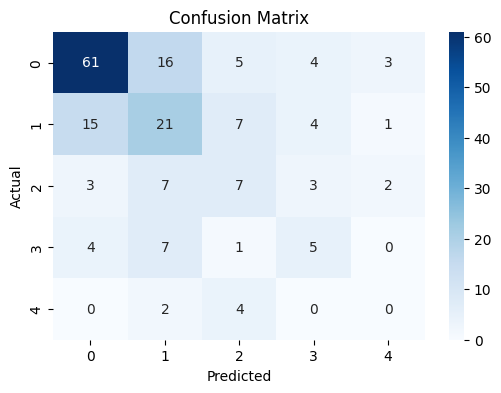

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


5. HYPERPARAMETER TUNING

In [ ]:
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print("\nBest Model Accuracy")
print(accuracy_score(y_test, y_pred_best))



Best Parameters
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}

Best Model Accuracy
0.5659340659340659


**6. MODEL EVALUATION AND ANALYSIS**

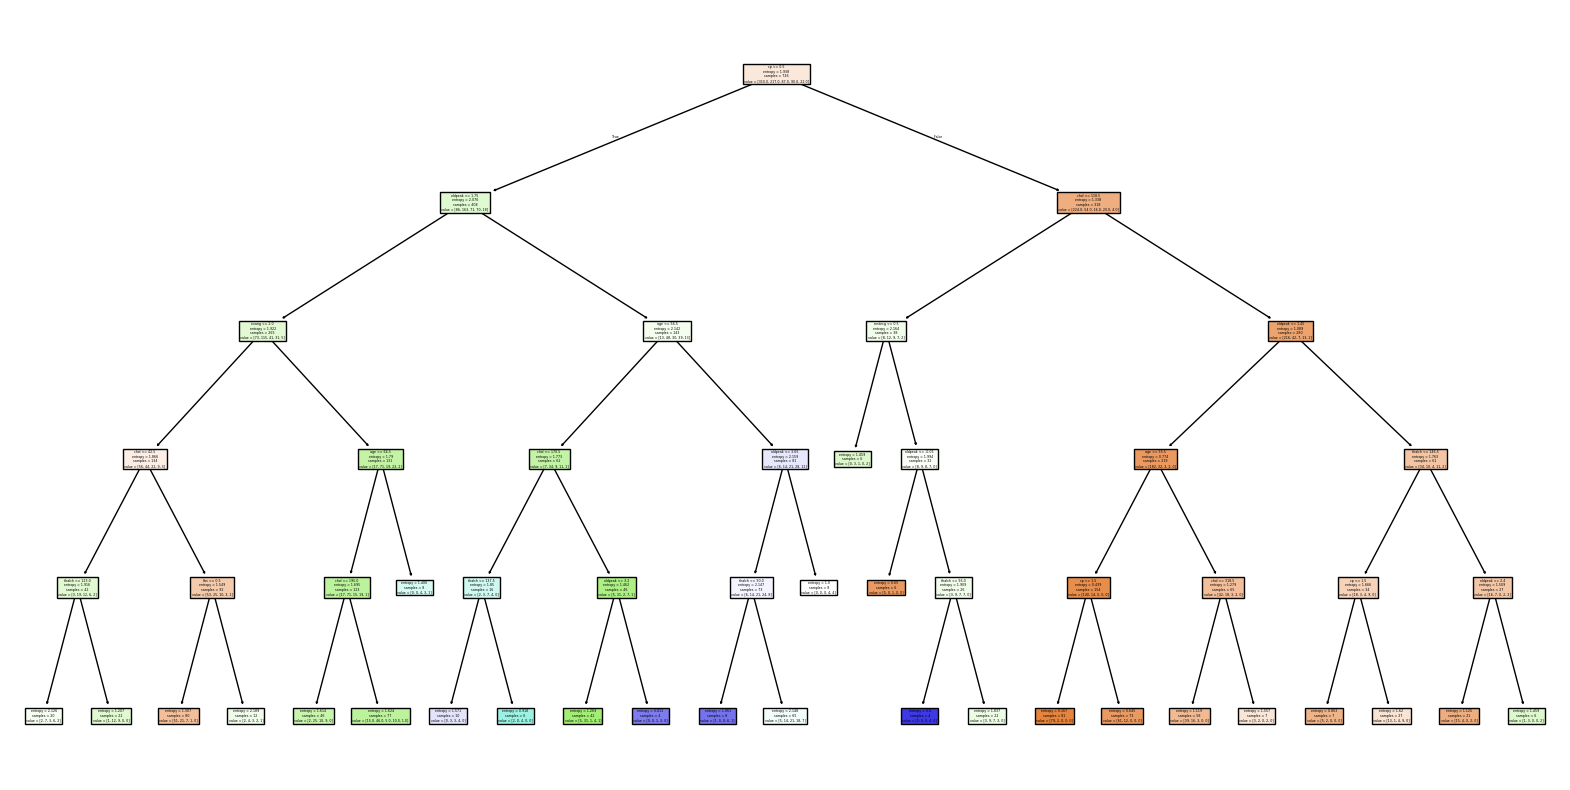

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    filled=True
)

plt.show()

In [ ]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(importance)


Feature Importance
     Feature  Importance
2         cp    0.302138
9    oldpeak    0.201383
4       chol    0.193614
0        age    0.111560
7     thalch    0.097395
8      exang    0.050482
5        fbs    0.023786
6    restecg    0.019642
3   trestbps    0.000000
1        sex    0.000000
10     slope    0.000000
11      thal    0.000000


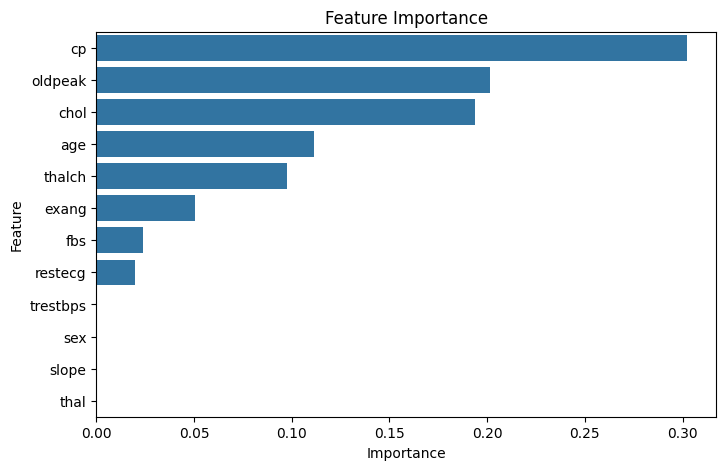

In [ ]:
# Feature Importance Plot

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

# Interview Questions:

**1. What are some common hyperparameters of Decision Tree models, and how do they affect the model's performance?**

*Answer:*

Decision Tree models have several hyperparameters that control how the tree is built and how well it generalizes to unseen data.

max_depth: Limits the maximum depth of the tree. A larger depth can increase accuracy but may lead to overfitting.
min_samples_split: Specifies the minimum number of samples required to split a node. Higher values reduce overfitting by preventing unnecessary splits.
min_samples_leaf: Defines the minimum number of samples required in a leaf node. It helps create more generalized models.
criterion: Determines the quality of a split. Common options are:
Gini Index
Entropy (Information Gain)

**Difference Between Label Encoding and One-Hot Encoding**

Label Encoding and One-Hot Encoding are techniques used to convert categorical data into numerical form so that machine learning algorithms can process it.

Label Encoding assigns a unique integer value to each category. For example, if a feature contains categories such as Red, Blue, and Green, they may be encoded as 0, 1, and 2 respectively. This method is simple and uses only one column, but it may introduce an artificial order among categories.

One-Hot Encoding creates a separate binary column for each category. For example, the categories Red, Blue, and Green are represented using three columns, where the value is 1 for the corresponding category and 0 for the others. This method avoids introducing any order among categories and is generally preferred for nominal data.